# MNIST Project Tasks-2



# Task 1
**Write the training loop**

In [1]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torchvision
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot  as plt

In [2]:
train_data= torchvision.datasets.MNIST(
    root="./folder",
    train=True,
    download= True,
    transform= transforms.ToTensor(),
)

test_data= torchvision.datasets.MNIST(
    root="./folder",
    train=False,
    download= True,
    transform= transforms.ToTensor(),
)

pixel= train_data.data.float()/255

mean=pixel.mean()
std= pixel.std()

print(mean)
print(std)

transformation= transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
])

train_data= torchvision.datasets.MNIST(
    root="./folder",
    train=True,
    download= True,
    transform= transformation,
)

test_data= torchvision.datasets.MNIST(
    root="./folder",
    train=False,
    download= True,
    transform= transformation,
)

augmentation_transform= transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomCrop(28,padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean,std),
    
])

train_data= torchvision.datasets.MNIST(
    root="./folder",
    train=True,
    download= True,
    transform= augmentation_transform,
)

train_loader=torch.utils.data.DataLoader(
    train_data,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader=torch.utils.data.DataLoader(
    test_data,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.features=nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier= nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7,128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128,10)

        )
    def forward(self,x):
        x=self.features(x)
        x=self.classifier(x)

        return x
    

tensor(0.1307)
tensor(0.3081)


Training Loop Pattern-
1. Zero gradients- by default the gradient gets added up, thus to clear off the previous gradient we do
clear gradients.

2.forward pass- We let the model understand the relationships/patterns and give it to the next hidden layer.

3. Compute Loss- Then we compute the loss, by using loss functions such as MSE, Cross Entropy Loss etc.

4. Then we go backward and with  the help of a optimizer adjust the weights accordingly.

Loss Functions

NLL Loss - Stands for Negative Log Likelihood Loss, it basically is a loss function for classification type problems where , it takes in log of probability answer, and rewards model for right prediction and punishes the model when bad prediction.

Cross Entropy Loss- Basically same as NLL , but we dont have send in log of probabilites , input is raw logit and it automatically applies softmax to change it to probabiltiy.

Optimizers-
SGD- stoachistic Gradient Descent- Basically a type of mini batch gradient descent, where it only looks at certain sections of training data at a time to optmize.

Adam Optimizer- Basically combines momentum and RMS prop for gradient Descent. Momentum helps in remebering past gradient as well as current and gives importance more to current. Rms prop also caluactes the square of the gradient, such that if there are large and small descent , thus each parameter gets its adaptive gradients.

In [7]:
criterion= nn.CrossEntropyLoss()

model=MNISTModel()
optimizer= torch.optim.Adam(model.parameters(), lr=0.001)

scheduler= torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)


num_epoch=7

for epoch in range(num_epoch):
    model.train()
    running_loss=0
    for images,labels in train_loader:
        optimizer.zero_grad()
        output= model(images)
        loss= criterion(output,labels)
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()
    scheduler.step()
    print(f"Loss ={running_loss/len(train_loader)} ")

Loss =0.5471582983189555 
Loss =0.26140070083870814 
Loss =0.21555190065156804 
Loss =0.16068540911462262 
Loss =0.14814616609285317 
Loss =0.1412109574819329 
Loss =0.13454935882788605 


# Task 2 
**Evaluate the model**

Model.eval()- basically tells the model that we are done with training , now we will do testing.

Basically it just turns off two things-

1. Dropout- We dont want any neuron while testing to just turn off, we want the best prediction as possible, thus dropout shoudl be turned off.

2. batchnorm- Basically the normalization during testing is used by the running averag eand runnign std, instead of calcuating it again anad again.

torch.no_grad()- basically stops computing the gradients, because we dont to calcuate gradients while testing, thus it also speds up computation and memory.

In [14]:
cor=0
tot =0
totloss=0

model.eval()
with torch.no_grad():
    for images,labels in test_loader:
        output=model(images)
        _,predict= torch.max(output,1)
        loss=criterion(output,labels)
        totloss+=loss.item()
        tot+=labels.size(0)
        cor+= (predict==labels).sum().item()
        print(f"Batch Loss = {loss.item()}")
        

avgloss= totloss/len(test_loader)
accuracy= (cor/tot)*100

print(f"Total loss = {avgloss}")

print(f" Test Accuracy = {accuracy}")


Batch Loss = 0.008383329957723618
Batch Loss = 0.01582234352827072
Batch Loss = 0.03971070796251297
Batch Loss = 0.03673214465379715
Batch Loss = 0.0506846159696579
Batch Loss = 0.02704796753823757
Batch Loss = 0.04625239595770836
Batch Loss = 0.031902506947517395
Batch Loss = 0.08253137022256851
Batch Loss = 0.07848571985960007
Batch Loss = 0.016636528074741364
Batch Loss = 0.045299530029296875
Batch Loss = 0.0021057957783341408
Batch Loss = 0.04134447127580643
Batch Loss = 0.05120988190174103
Batch Loss = 0.0312553346157074
Batch Loss = 0.10545426607131958
Batch Loss = 0.008789772167801857
Batch Loss = 0.015157575719058514
Batch Loss = 0.08508697897195816
Batch Loss = 0.026575403288006783
Batch Loss = 0.04202176257967949
Batch Loss = 0.05548272654414177
Batch Loss = 0.04641503095626831
Batch Loss = 0.005281142424792051
Batch Loss = 0.042951323091983795
Batch Loss = 0.03917258232831955
Batch Loss = 0.02990495227277279
Batch Loss = 0.003903187345713377
Batch Loss = 0.09149275720119476


In [10]:
cor=0
tot =0
totloss=0

model.eval()
with torch.no_grad():
    for images,labels in train_loader:
        output=model(images)
        _,predict= torch.max(output,1)
        loss=criterion(output,labels)
        totloss+=loss.item()
        tot+=labels.size(0)
        cor+= (predict==labels).sum().item()
        

avgloss= totloss/len(test_loader)
accuracy= (cor/tot)*100

print(f"Total loss = {avgloss}")

print(f" Train Accuracy = {accuracy}")


Total loss = 0.39690013711672917
 Train Accuracy = 97.97333333333333


Thus our training accuracy is around 97% and test accuracy is around 98%, thus it indicates that our model is doing very good, overfitting would look something like having training accuracy around 98 and test accuracy very less around 80 %.

# Task 3 
**Save, load & reflect

Saving we have two options

1. Save the entire model- saves everything, the model, architecture, weights, biases everything, but problem is if we use it somewhere else, and rename the class or move files here and there it might not work.

2. Saving only the state dict -
It basically stores and saves a dictionary, with layer weights, layer biases and batchnorm params. Only learned parameters are stored and Architure is not stored. This is more recommended way of saving a model. This also makes the file smaller.



In [11]:
torch.save(model.state_dict(),"mnist_task2model.pth")



In [12]:
model = MNISTModel()
model.load_state_dict(torch.load("mnist_task2model.pth"))
model.eval()


images,labels = next(iter(test_loader))

img= images[0].unsqueeze(0)
output= model(img)

_,prediction = torch.max(output,1)

print("Predicited = ",prediction.item())
print("Actual number = ", labels[0].item())

c:\Users\Anushree\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicited =  7
Actual number =  7


Now for training loss , we have already shown above the loss across the epochs, now i didnt save those in an array, so instead of training again i will just manually add them.


In [20]:
train_loss=[0.5471582983189555 , 0.26140070083870814 , 0.21555190065156804 ,0.16068540911462262, 0.14814616609285317 ,0.1412109574819329 ,0.13454935882788605  ]



In [16]:
model.eval()

correct=0;
total=0;

test_accuracy=[]
with torch.no_grad():
    for epoch in range(num_epoch):
        for images,labels in train_loader:
            output=model(images)
            _,predict= torch.max(output,1)
            total+=labels.size(0)
            correct+= (predict==labels).sum().item()
        test_accuracy.append((correct/total)*100)
        print(f"Epoch {epoch+1} Test Accuracy = {(correct/total)*100}")

c:\Users\Anushree\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1 Test Accuracy = 98.03166666666667
Epoch 2 Test Accuracy = 98.00083333333333
Epoch 3 Test Accuracy = 98.00111111111111
Epoch 4 Test Accuracy = 98.00333333333333
Epoch 5 Test Accuracy = 97.98566666666667
Epoch 6 Test Accuracy = 97.99972222222222
Epoch 7 Test Accuracy = 98.00285714285715


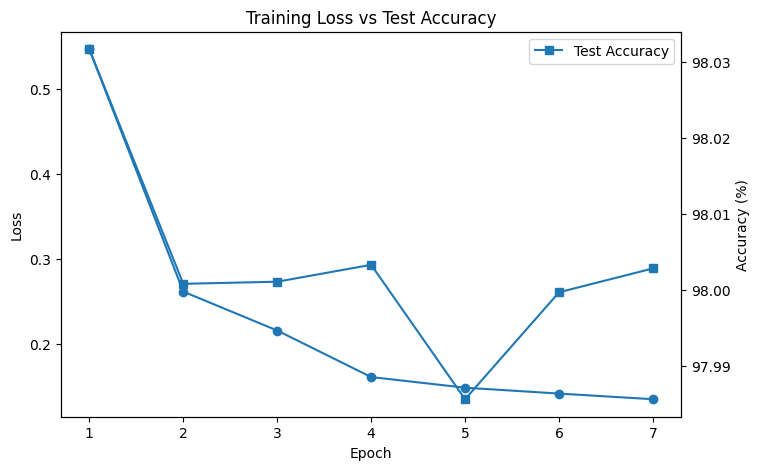

In [22]:

num_epochs=7
epochs = range(1, num_epochs + 1)

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(
    epochs,
    train_loss,
    marker='o',
    label='Train Loss'
)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2 = ax1.twinx()

ax2.plot(
    epochs,
    test_accuracy,
    marker='s',
    label='Test Accuracy'
)
ax2.set_ylabel('Accuracy (%)')

plt.title('Training Loss vs Test Accuracy')
plt.legend(loc='upper right')

plt.show()

To imporve the model, we can maybe train it for more number of epoch and also increase the number of layers, but like a 98 percent accuracy is pretty good and further improvisation may lead to overfitting. We can also tweek the learning rate and batchnormalization parameters and try.